# Evolutionary Simulation Analysis

This notebook presents a complete workflow for analyzing how different testing and intervention policies shape epidemic outcomes, and how the resulting transmission dynamics relate to the viral evolutionary patterns generated in the simulation.

The goal is to connect **policy performance**, **true transmission structure**, and **sequence‑based phylogenetic signals**.

## Overview

We run multiple evolutionary simulations under several policy settings and evaluate:

1. **How quickly diagnosis‑based triggers detect true transmission signals**  
2. **How strongly each intervention reduces total infections**  
3. **How testing and sequencing volumes differ across policies**  
4. **How the infection log’s transmission tree compares to the mutation‑based evolutionary tree**

## 1) Policy Evaluation

We test multiple combinations of:

- testing intensity  
- intervention strength  
- trigger rules  
- random seeds  

For each simulation, we compute:

- detection delay  
- total infections  
- total diagnoses  
- total sequences  
- timing of interventions  

## 2) Detailed Outbreak Timeline

For each policy, we visualize:

- daily and cumulative infections  
- diagnoses and sequences  
- ground‑truth triggers (based on true infections)  
- diagnosis triggers (based on observed diagnoses)  
- intervention start times  
- detection day  

## 3) Transmission Tree Reconstruction

Using the infection log, we reconstruct the **true transmission tree**, where each node represents an infection event (`agentID_day`).  
Sequenced individuals are highlighted to show sampling coverage.

This tree reflects the actual “who‑infected‑whom” structure of the outbreak and provides a baseline for comparing against sequence‑based trees.


In [ ]:
import yaml
import os
import sys
import json
import numpy as np
import covasim as cv
import matplotlib.pyplot as plt

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [ ]:
print("PWD =", os.getcwd())

sys.path.append("../intervention_search")

from simulation.runner import run_evo_simulation
from analysis.metrics import summarize_detection, summarize_intervention, summarize_outbreak
from analysis.mutation_tree import build_mutation_tree
from plotting.plot_mutation_tree import plot_mutation_tree

PWD = /home/jhkim/covasim_project/jhk_covasim4wastewater/weekly_reports


In [ ]:
RAW_DIR = "../intervention_search/results/raw"
PROC_DIR = "../intervention_search/results/processed"
FIG_DIR = "../intervention_search/results/figures"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
with open("../intervention_search/configs/sim_pars.yaml") as f:
    sim_pars = yaml.safe_load(f)

with open("../intervention_search/configs/evo_pars.yaml") as f:
    evo_pars = yaml.safe_load(f)

with open("../intervention_search/configs/intervention_policies.yaml") as f:
    intervention_policies = yaml.safe_load(f)["intervention_policies"]

In [6]:
policy_dict = {
    "baseline": intervention_policies["baseline"],
    "policy_A": intervention_policies["policy_A"],
    "policy_B": intervention_policies["policy_B"],
    "policy_C": intervention_policies["policy_C"],
}

## Policy Overview

All policies share the same trigger mechanism:  
a **diagnosis‑based weekly growth trigger** that activates an intervention when observed cases increase rapidly.  
However, once the trigger fires, **each policy applies a different intervention**, with distinct levels of testing, sequencing, and transmission reduction globally.

### **Baseline**
- No intervention is applied even if the trigger condition is met.
- Moderate testing and sequencing. (p_test=0.35, p_seq=0.25)
- Serves as the reference scenario for comparison.

### **Policy A: High Testing, Weak Distancing**
- Higher testing and sequencing rates. (p_test=0.50, p_seq=0.30)
- Only a mild reduction in transmission during intervention. (10%)
- Short intervention duration.
- Represents an early detection through testing, but weak suppression strategy.

### **Policy B: Low Testing, Strong Distancing**
- Lower testing and sequencing. (p_test=0.25, p_seq=0.10)
- Strong reduction in transmission once intervention starts. (40%)
- Includes a quiet period to prevent repeated triggering.
- Represents a late detection due to low testing, but strong suppression once activated strategy.

### **Policy C: Balanced Testing and Distancing**
- Testing and sequencing at moderate levels. (p_test=0.35, p_seq=0.25)
- Moderate reduction in transmission. (25%)
- Short quiet period and short intervention duration.
- Represents a balanced middle‑ground strategy between A and B.

### **Summary**
Although all policies use the **same trigger rule**,  
they differ substantially in:

- **Testing intensity (p_test, p_seq)**  
- **Strength of distancing (beta reduction)**  
- **Intervention duration**  
- **Quiet period behavior**

These differences allow us to evaluate how detection speed and intervention strength jointly influence outbreak outcomes.


In [ ]:
N_ENSEMBLE = 500
results_by_policy = {name: [] for name in policy_dict.keys()}

for pname, policy in policy_dict.items():
    print(f"Running ensemble for {pname}...")
    for seed in range(N_ENSEMBLE):
        sim, obs, interv, delay, results = run_evo_simulation(
            sim_pars=sim_pars,
            evo_pars=evo_pars["evo_pars"],
            policy=policy,
            rand_seed=seed,
        )

        det = summarize_detection(results)          # returns: first_detection_day, detection_delay, detection_success_window
        intv = summarize_intervention(results)   # returns: detection_day, first_intervention_day, intervention_delay, intervention_success
        impact = summarize_outbreak(sim, interv)     # returns: total_infections, peak_infections, ...

        total_diag = int(np.sum(obs.daily_diagnoses))
        total_seq = int(np.sum(obs.daily_sequences))

        result = {
            "policy": pname,
            "seed": seed,
            "detection_day": det["first_detection_day"],
            "detection_delay": delay,
            "intervention_day": intv["first_intervention_day"],
            "intervention_delay": intv["intervention_delay"],
            "total_infections": impact["total_infections"],
            "peak_infections": impact["peak_infections"],
            "total_diagnoses": total_diag,
            "total_sequences": total_seq,
        }

        results_by_policy[pname].append(result)

print("All ensembles complete.")

import pandas as pd

# flatten
rows = []
for pname, results in results_by_policy.items():
    for r in results:
        rows.append(r)

df = pd.DataFrame(rows)

# save
df.to_csv("results_by_policy.csv", index=False)

print("Saved results_by_policy.csv")

Running ensemble for baseline...
Running ensemble for policy_A...
Running ensemble for policy_B...
Running ensemble for policy_C...
All ensembles complete.
Saved results_by_policy.csv


/tmp/ipykernel_1114/2576859628.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


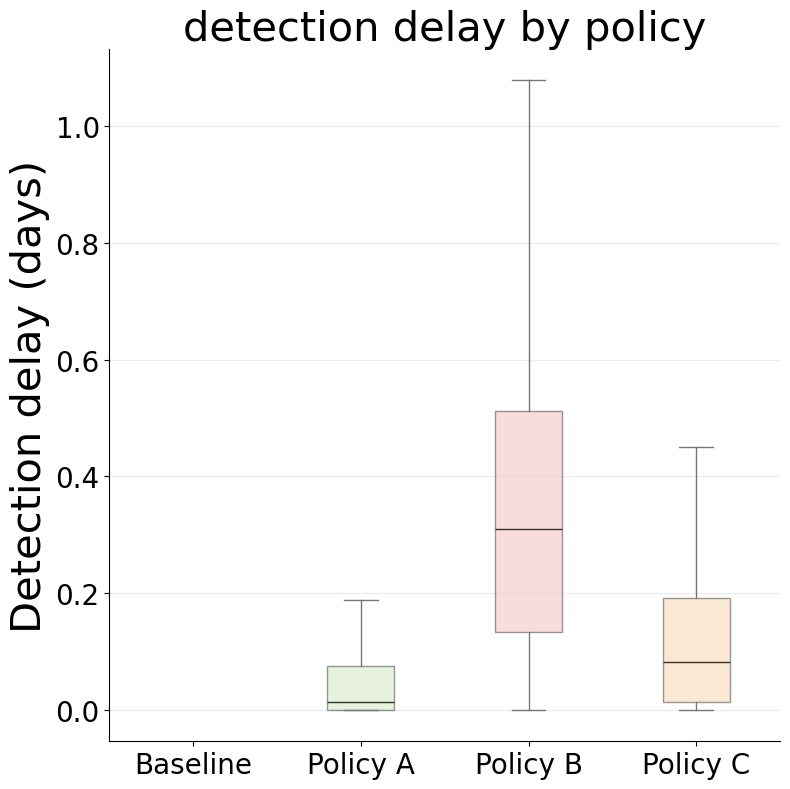

/tmp/ipykernel_1114/2576859628.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


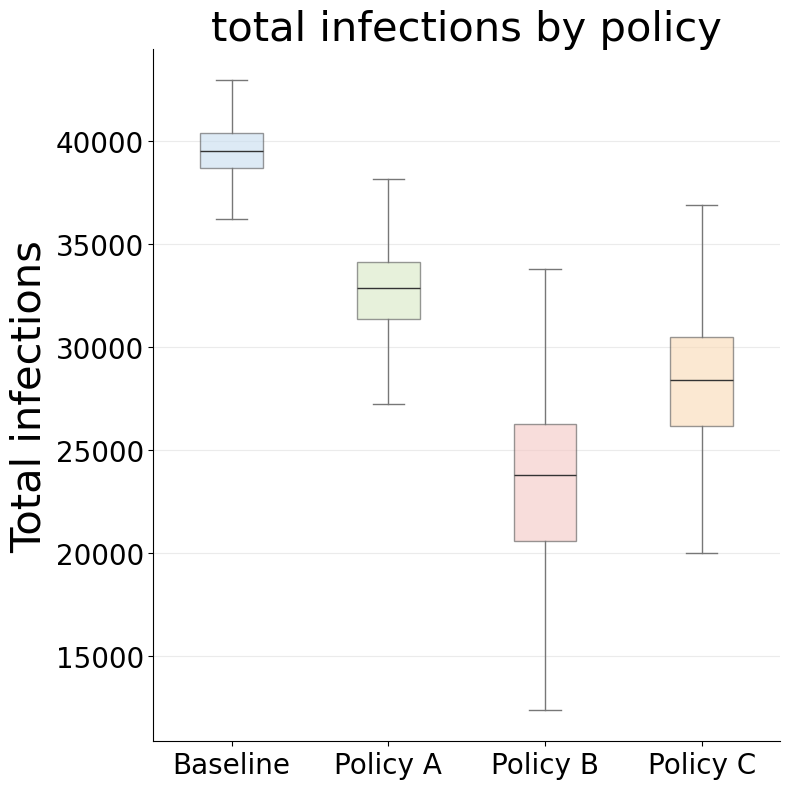

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("results_by_policy.csv")

policy_names = df["policy"].unique().tolist()

def grouped_boxplot_from_csv(df, metric_key, ylabel, filename):
    data = []
    labels = []
    label_map = {
        "policy_A": "Policy A",
        "policy_B": "Policy B",
        "policy_C": "Policy C",
        "baseline": "Baseline"
    }

    for pname in policy_names:
        vals = df[df["policy"] == pname][metric_key].dropna().tolist()
        data.append(vals)
        labels.append(label_map.get(pname, pname))

    fig, ax = plt.subplots(figsize=(8, 8))

    boxprops    = dict(linewidth=1, color="#555555")
    whiskerprops= dict(linewidth=1, color="#777777")
    capprops    = dict(linewidth=1, color="#777777")
    medianprops = dict(linewidth=1, color="#333333")
    flierprops  = dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.4)

    bp = ax.boxplot(
        data,
        labels=labels,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=flierprops,
        patch_artist=True,
        showfliers=False,
        widths=0.4
    )

    colors = ["#c7dcef", "#d7e8c4", "#f4c7c3", "#f9d9b5"]
    for patch, color in zip(bp['boxes'], colors[:len(labels)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_ylabel(ylabel, fontsize=30)
    if metric_key == 'detection_delay':
        ax.set_title(f"detection delay by policy", fontsize=30)
    else:
        ax.set_title(f"total infections by policy", fontsize=30)

    ax.tick_params(axis='both', labelsize=20)

    ax.grid(axis="y", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=900)
    plt.show()
    plt.close(fig)

grouped_boxplot_from_csv(df, "detection_delay", "Detection delay (days)", "box_detection_delay.png")
grouped_boxplot_from_csv(df, "total_infections", "Total infections", "box_total_infections.png")


In [ ]:
def plot_detailed_policy_run(pname):
    r = sorted(results_by_policy[pname], key=lambda x: x["seed"])[0]
    seed = r["seed"]
    sim, obs, interv, _, results  = run_evo_simulation(
        sim_pars=sim_pars,
        evo_pars=evo_pars["evo_pars"],
        policy=policy_dict[pname],
        rand_seed=seed,
    )

    T = sim.npts
    days = np.arange(T)

    new_inf = sim.results["new_infections"]
    diag = obs.daily_diagnoses
    seqs = obs.daily_sequences

    cum_inf = np.cumsum(new_inf)
    cum_diag = np.cumsum(diag)

    # triggers
    gt_triggers = getattr(interv, "gt_triggers", []) 
    diag_triggers = getattr(interv, "diag_triggers", [])


    fig, ax = plt.subplots(figsize=(12, 7))


    # cumulative curves (solid lines)
    ax.plot(days, cum_inf, label="Cum infections", color="tab:blue", linestyle="-", zorder=1)
    ax.plot(days, cum_diag, label="Cum diagnoses", color="tab:orange", linestyle="-", zorder=1)

    ax2 = ax.twinx()

    if len(gt_triggers) > 0:
        ax.scatter(gt_triggers,
                   cum_inf[gt_triggers],
                   color="red", s=5, label="GT triggers", zorder=5)

    # D triggers → dot on cumulative diagnoses
    if len(diag_triggers) > 0:
        ax.scatter(diag_triggers,
                   cum_diag[diag_triggers],
                   color="blue", s=5, label="D triggers", zorder=5)

    ax.set_xlabel("Day")
    ax.set_ylabel("Count")
    ax.set_title(f"Detailed timeline for policy: {pname}")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"detailed_{pname}.png"), dpi=200)
    plt.show()
    plt.close(fig)


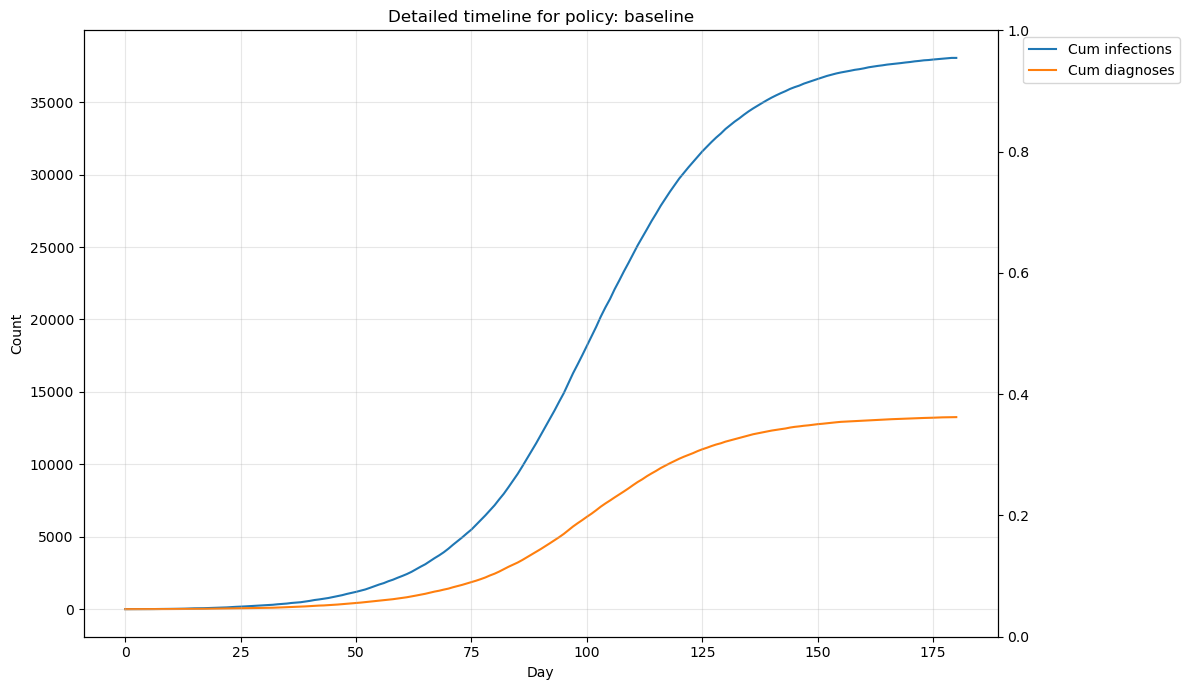

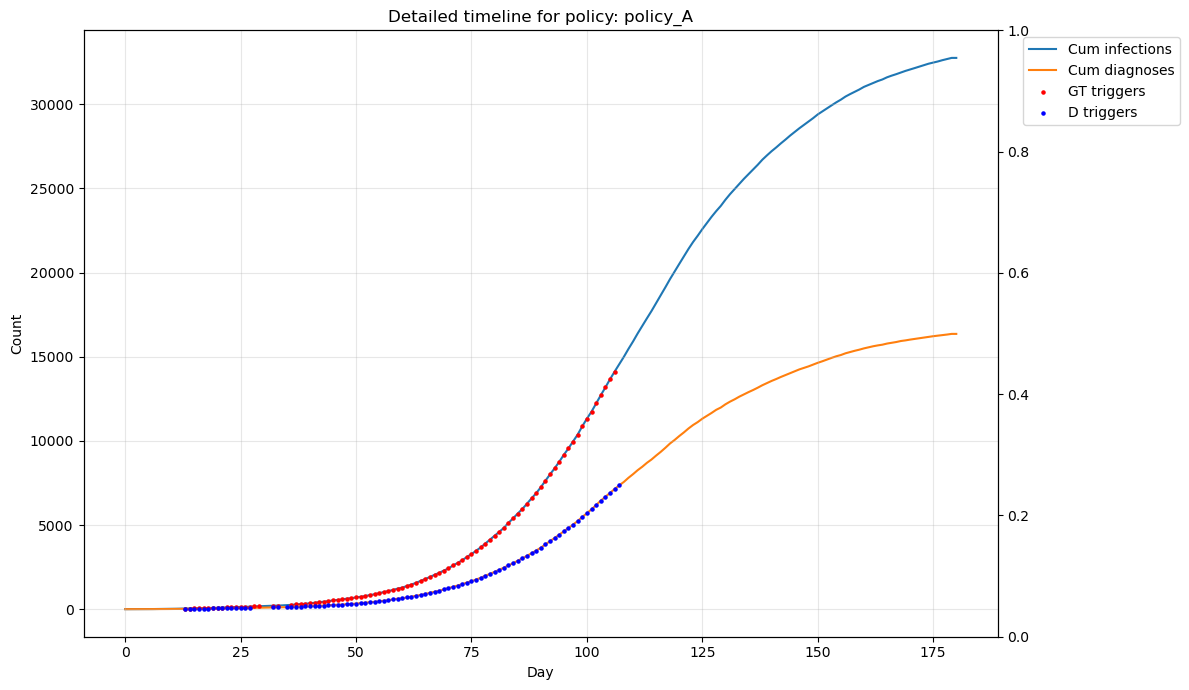

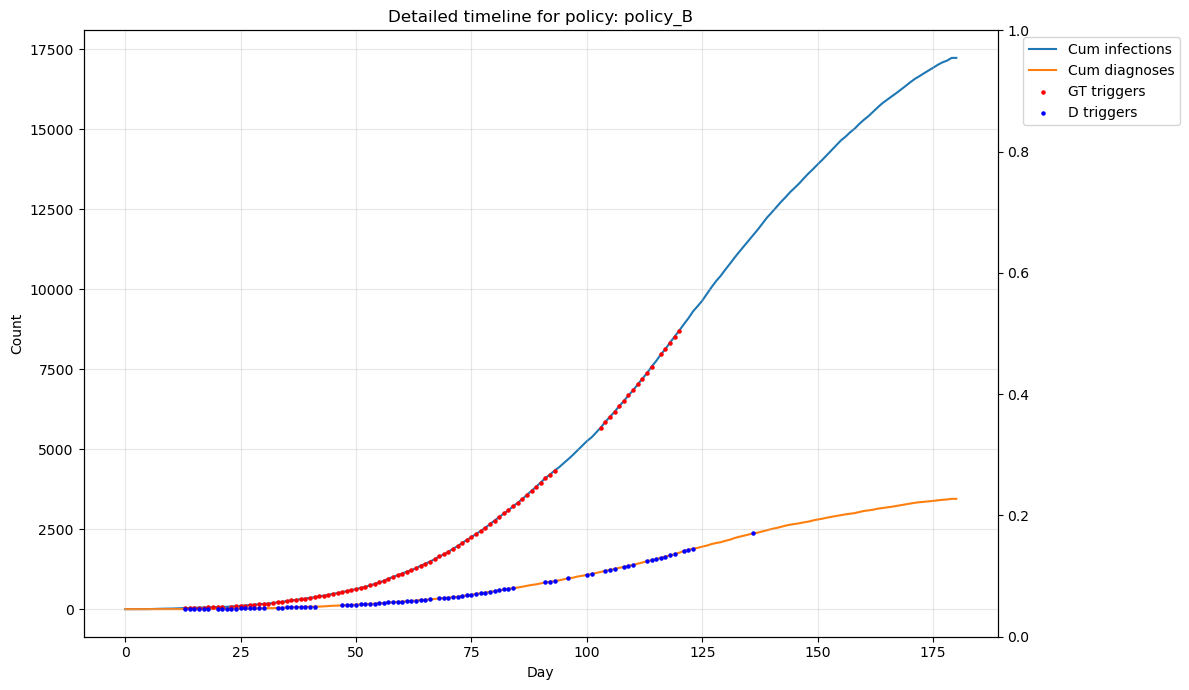

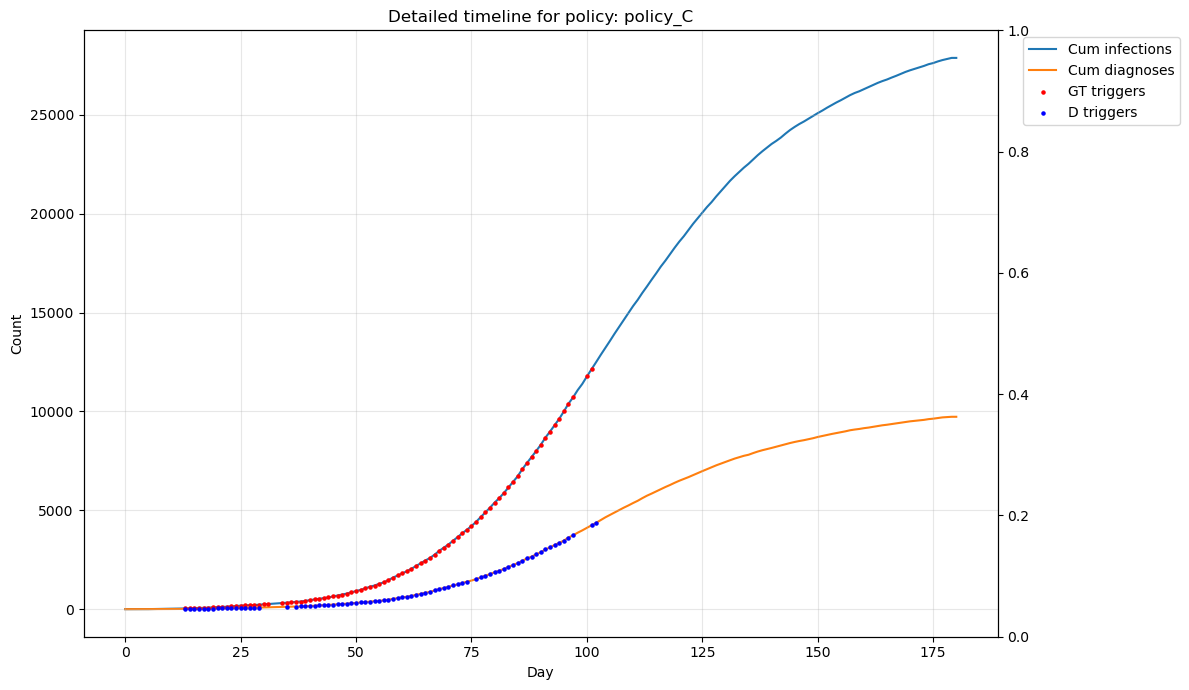

In [9]:
for pname in policy_names:
    plot_detailed_policy_run(pname)

Across all simulations, the strongest distancing combined with low testing produced the lowest total infections. The next best outcome came from the balanced policy with moderate distancing and moderate testing. The least effective was the high‑testing but weak‑distancing policy, where early detection did not compensate for insufficient suppression.

In [ ]:
policy_name = "policy_B"
policy_run = sorted(results_by_policy[policy_name], key=lambda x: x["seed"])[0]
seedB = policy_run["seed"]

simB, obsB, intervB, _, results = run_evo_simulation(
    sim_pars=sim_pars,
    evo_pars=evo_pars["evo_pars"],
    policy=policy_dict[policy_name],
    rand_seed=seedB,
)

sequenced_agents = set()
for day_list in obsB.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(simB, daily_sequenced_agents=sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policyB_full.png"),
    detection_day=policy_run["detection_day"],
    sequenced_only=False,
    collapse=False,
)


TypeError: build_mutation_tree() got an unexpected keyword argument 'sequenced_agents'

In [ ]:
def plot_all_policies_side_by_side(policy_names):
    n = len(policy_names)
    fig, axes = plt.subplots(1, n, figsize=(12*n, 9), sharey=True)

    for i, pname in enumerate(policy_names):
        ax = axes[i]

        r = sorted(results_by_policy[pname], key=lambda x: x["seed"])[0]
        seed = r["seed"]
        sim, obs, interv, _, results  = run_evo_simulation(
            sim_pars=sim_pars,
            evo_pars=evo_pars["evo_pars"],
            policy=policy_dict[pname],
            rand_seed=seed,
        )

        T = sim.npts
        days = np.arange(T)

        new_inf = sim.results["new_infections"]
        diag = obs.daily_diagnoses
        cum_inf = np.cumsum(new_inf)
        cum_diag = np.cumsum(diag)

        gt_triggers = getattr(interv, "gt_triggers", [])
        diag_triggers = getattr(interv, "diag_triggers", [])

        # main curves
        ax.plot(days, cum_inf, label="Cum infections", color="tab:blue", zorder=1)
        ax.plot(days, cum_diag, label="Cum diagnoses", color="tab:orange", zorder=1)

        # triggers
        if len(gt_triggers) > 0:
            ax.scatter(gt_triggers, cum_inf[gt_triggers],
                       color="red", s=8, label="Infections Trigger", zorder=5)

        if len(diag_triggers) > 0:
            ax.scatter(diag_triggers, cum_diag[diag_triggers],
                       color="blue", s=8, label="Diagnoses Trigger", zorder=5)

        ax.set_title(pname, fontsize=30)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=15)

        if i == 0:
            ax.set_ylabel("Count", fontsize=20)
            ax.set_xlabel("")
        fig.supxlabel("Day", fontsize=20)
        

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=20)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "policies_side_by_side.png"), dpi=300)
    plt.show()


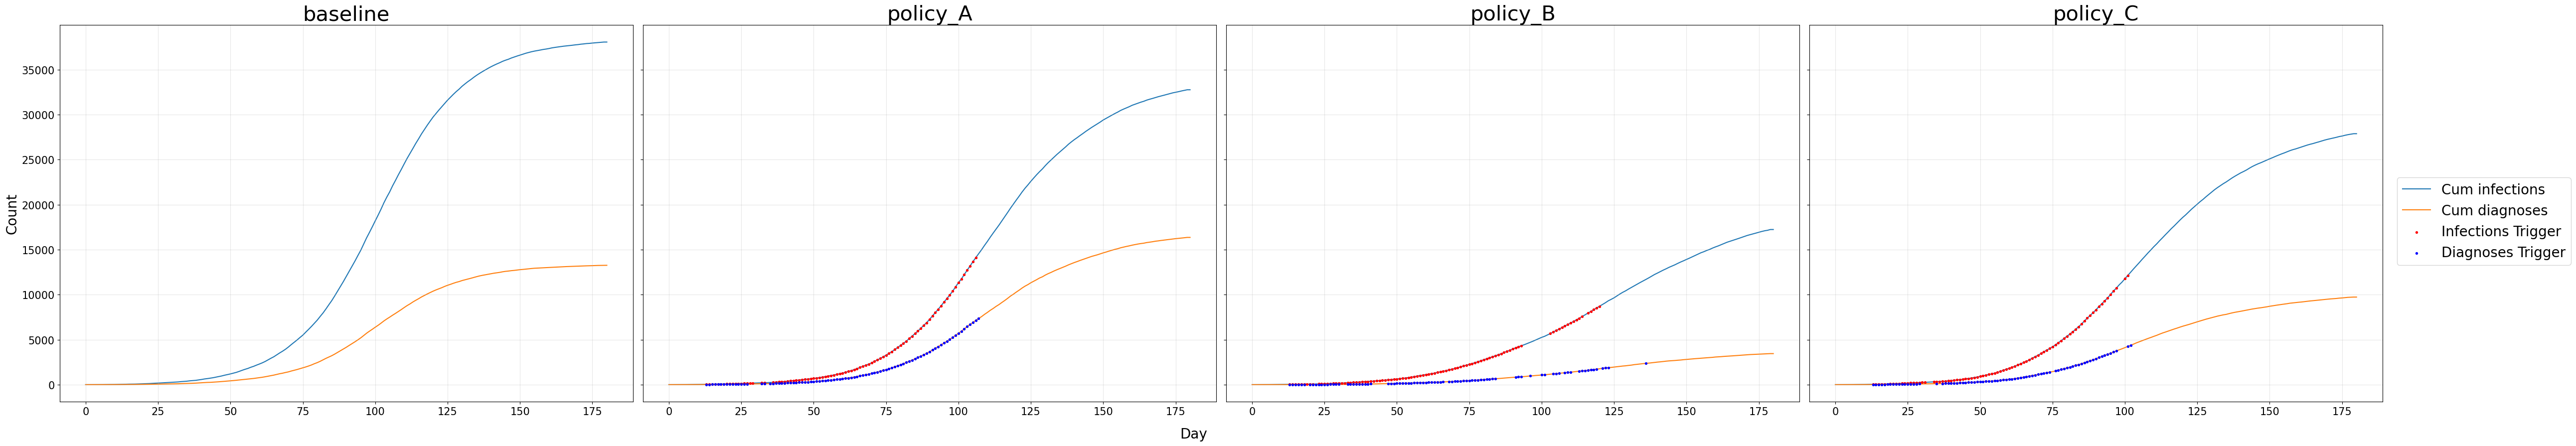

In [ ]:
plot_all_policies_side_by_side(policy_names)